In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ks_2samp
import itertools
from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit
import math
from matplotlib.lines import Line2D

import os
while not os.path.isdir('.git'):
    os.chdir('..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

In [29]:
project = "temporal-interference-1"

colors = {
    "No TI": "#0D0887",
    "0 Hz TI": "#B12A90",
    
    "5 Hz TI": "#E16462",
    "130 Hz TI": "#FCA636"
}

mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

idxs = np.arange(0, 20)

types = {
    "No TI": "noTI_0.1",
    "0 Hz TI": "1000_0_0.32_0.1",
    "5 Hz TI": "1000_5_0.9_0.1",
    "130 Hz TI": "1000_130_0.9_0.1"
}

# Natural Input Figure

## Protocol

In [3]:
spike_times = pd.read_csv(f"output/{project}/in_vivo_stimuli.csv", index_col = 0).to_numpy()

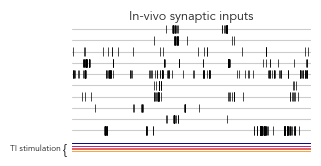

In [32]:
fig = plt.figure(figsize = (8.4, 14))

outer_gs = gridspec.GridSpec(9, 1, height_ratios = [1, 0.2, 2.5, 0.5, 0.7, 0.25, 0.7, 0.25, 0.7])

# --- A and B panels ---

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(5, 4, subplot_spec = outer_gs[0], width_ratios = [0.1, 0.3, 0.01, 0.3], height_ratios = [0.9, 0.01, 0.01, 0.01, 0.01], hspace = 0.05)

### A

ax_a = fig.add_subplot(inner_gs_1[0, 1])

for i, spikes in enumerate(spike_times.T):
    ax_a.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax_a.set_ylim(0, 11)
ax_a.set_yticks(np.arange(1, 11, 1))
ax_a.set_yticklabels([])

ax_a.set_xlabel("")
ax_a.set_xlim(0, 100000)
ax_a.tick_params(axis = "x", labelbottom = False, which = "both", bottom = False)

ax_a.grid(True)
ax_a.xaxis.grid(False)
ax_a.yaxis.grid(True)

sns.despine(ax = ax_a, top = True, bottom = True, left = True, right = True)

ax_a.set_title("In-vivo synaptic inputs", y = 0.925)

################## The NO TI line

ax = fig.add_subplot(inner_gs_1[1, 1])

ax.axvspan(
    0,
    3000,
    color = colors["No TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The 0 Hz TI line

ax = fig.add_subplot(inner_gs_1[2, 1])

ax.axvspan(
    0,
    3000,
    color = colors["0 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The 5 Hz TI line

ax = fig.add_subplot(inner_gs_1[3, 1])

ax.axvspan(
    0,
    3000,
    color = colors["5 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The 130 Hz TI line

ax = fig.add_subplot(inner_gs_1[4, 1])

ax.axvspan(
    0,
    3000,
    color = colors["130 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.21, 0.78665, "TI stimulation", fontsize = 6, va = "center", ha = "center")
fig.text(0.245, 0.78665, "{", fontsize = 10, va = "center", ha = "center")

plt.savefig("bernstein-natural-1-protocol.png", dpi = 500, bbox_inches = "tight", transparent = True)

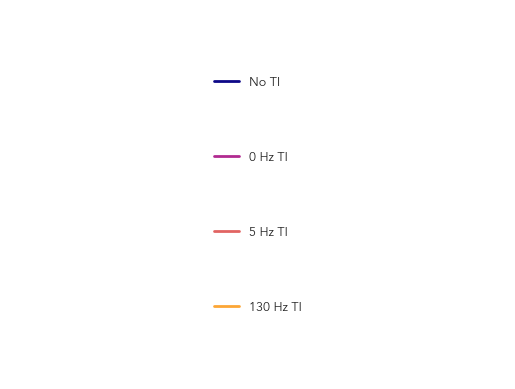

In [34]:
fig, ax = plt.subplots()

# Dummy handles for the legend
handles = [
    Line2D([0], [0], color = colors["No TI"], lw = 2, label = "No TI"),
    Line2D([0], [0], color = colors["0 Hz TI"], lw = 2, label = "0 Hz TI"),
    Line2D([0], [0], color = colors["5 Hz TI"], lw = 2, label = "5 Hz TI"),
    Line2D([0], [0], color = colors["130 Hz TI"], lw = 2, label = "130 Hz TI")
]

# Hide the axes
ax.axis("off")

# Add only the legend
legend = ax.legend(handles=handles, frameon=False, loc="center", labelspacing = 5)

# Save or show
plt.savefig("legend_only.png", bbox_inches = "tight", dpi = 300)
plt.show()

## Voltage traces

In [6]:
def read_voltage_trace(idx, time_start = 0, time_end = 10):
    global project

    conditions = {
        "No TI": f"output/{project}/{idx}/in-vivo/noTI_0.1/voltage.csv",
        "0 Hz TI": f"output/{project}/{idx}/in-vivo/1000_0_0.32_0.1/voltage.csv",
        "5 Hz TI": f"output/{project}/{idx}/in-vivo/1000_5_0.9_0.1/voltage.csv",
        "130 Hz TI": f"output/{project}/{idx}/in-vivo/1000_130_0.9_0.1/voltage.csv"
    }
    
    n_skip = int(time_start / 0.025 * 1000 + 1)
    print(f"Skipping {n_skip} rows")
    nrows = int(time_end / 0.025 * 1000 + 1 - n_skip)

    voltage = {}
    for (condition, filename) in conditions.items():
        voltage[condition] = pd.read_csv(filename, index_col = 0, nrows = nrows, skiprows = n_skip)
        voltage[condition].columns = ["Voltage", "Time"]

    return voltage

In [7]:
traces = read_voltage_trace(idx = 0, time_start = 75, time_end = 95)

Skipping 3000001 rows


In [8]:
def plot_trace(ax, condition, traces, remove_x, x_tick_step = 5):
    voltage = traces[condition].Voltage
    time = traces[condition].Time.to_numpy() / 1000
    time = time - time.min()

    ax.plot(
        time,
        voltage,
        linewidth = 1,
        color = colors[condition]
    )

    ax.set_ylim(-90, 70)

    ax.grid(True, alpha = 0.25)

    ax.set_yticks(np.arange(-50, 50 + 10, 50))
    ax.tick_params(left = True, labelleft = True)

    sns.despine(ax = ax, top = True, right = True)

    ax.set_ylabel("Voltage, mV", fontsize = 9)
    ax.set_xlabel("Time, s")
    
    min_time = math.floor(time[0])
    max_time = math.ceil(time[-1])
    
    ax.set_xlim(min_time, max_time)
    ax.set_xticks(np.arange(min_time, max_time + x_tick_step, x_tick_step))

    sns.despine(ax = ax, top = True, right = True, bottom = True)
    
    if remove_x:
        ax.set_xlabel("")
        ax.tick_params(bottom = False, labelbottom = False)

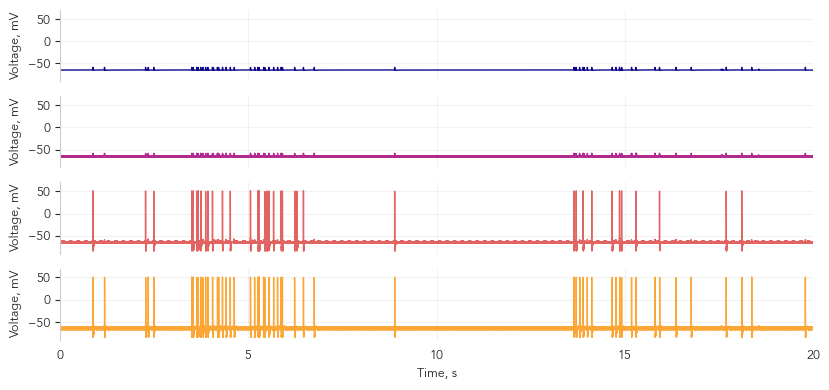

In [31]:
fig, axs = plt.subplots(nrows = 4, ncols = 1, figsize = (8.4, 4))

for i, condition in enumerate(traces.keys()):
    plot_trace(ax = axs[i], traces = traces, condition = condition, remove_x = i != len(traces) - 1)

plt.tight_layout()
plt.savefig("bernstein-natural-2.png", dpi = 500, bbox_inches = "tight")

## Weight dynamics and final weight distribution

In [11]:
def read_mean_weight(drop_duplicates = False):
    global project
    
    conditions = {
        "No TI": f"output/{project}/in-vivo/noTI_0.1/synapse_weight_statistics.csv",
        "0 Hz TI": f"output/{project}/in-vivo/1000_0_0.32_0.1/synapse_weight_statistics.csv",
        "5 Hz TI": f"output/{project}/in-vivo/1000_5_0.9_0.1/synapse_weight_statistics.csv",
        "130 Hz TI": f"output/{project}/in-vivo/1000_130_0.9_0.1/synapse_weight_statistics.csv"
    }
    
    weights = {}
    
    for (condition, filename) in conditions.items():
        print(f"Reading condition {condition}")
        weights[condition] = pd.read_csv(filename)
        weights[condition].Time = weights[condition].Time / 1000
        if drop_duplicates:
            weights[condition] = weights[condition].drop_duplicates(
                subset = "Mean",
                keep = "first",
                ignore_index = True
            )
    
    return weights

In [12]:
def drop_weight_duplicates(weights):
    weights = weights.copy()
    
    for condition in weights.keys():
        weights[condition] = weights[condition].drop_duplicates(
            subset = "Mean",
            keep = "first",
            ignore_index = True
        )
    
    return weights

In [13]:
mean_weights = read_mean_weight()

Reading condition No TI
Reading condition 0 Hz TI
Reading condition 5 Hz TI
Reading condition 130 Hz TI


In [14]:
mean_weights["No TI"]

,Time,Mean,SD,SEM
0,0.000000,0.100000,0.000000,0.000000
1,0.000025,0.100000,0.000000,0.000000
2,0.000050,0.100000,0.000000,0.000000
3,0.000075,0.100000,0.000000,0.000000
4,0.000100,0.100000,0.000000,0.000000
...,...,...,...,...
25199996,629.999900,0.242797,0.288749,0.020418
25199997,629.999925,0.242797,0.288749,0.020418
25199998,629.999950,0.242797,0.288749,0.020418
25199999,629.999975,0.242797,0.288749,0.020418


In [15]:
def rising_double_exp(t, a1, tau1, a2, tau2):
    w0 = 0.1 # known from experimental setup
    t0 = 0 # starting time is zero

    return w0 + a1 * (1 - np.exp(-(t - t0) / tau1)) + a2 * (1 - np.exp(-(t - t0) / tau2))

def rising_exp(t, a1, tau1):
    w0 = 0.1 # known from experimental setup
    t0 = 0 # starting time is zero

    return w0 + a1 * (1 - np.exp(-(t - t0) / tau1))

def fit_double_exponential(weights, time):
    w = np.array(weights).mean(axis = 0)
    t = np.array(time)

    popt, _ = curve_fit(
        f = rising_double_exp,
        xdata = t,
        ydata = w,
        p0 = [0.1, 1.0, 0.1, 2.0],
        bounds = ([0, 1e-6, 0, 1e-6], [100, 600, 100, 600])
    )
    a1, tau1, a2, tau2 = popt

    # Swap for consistency: tau1 always lower than tau2
    a1, tau1, a2, tau2 = (a2, tau2, a1, tau1) if tau1 > tau2 else (a1, tau1, a2, tau2)

    return rising_double_exp(t, a1, tau1, a2, tau2), {
        "a1": a1, "tau1": tau1, "a2": a2, "tau2": tau2
    }

def fit_exponential(weights, time):
    t = np.array(time)
    
    amp_guess = weights.max() - weights.min()

    popt, _ = curve_fit(
        f = rising_exp,
        xdata = t,
        ydata = weights,
        p0 = [amp_guess, 1.0],
        bounds = ([0, 1e-6], [100, 600])
    )
    a1, tau1 = popt

    return rising_exp(t, a1, tau1), {
        "a1": a1, "tau1": tau1
    }


fit = []

for (condition, weight) in mean_weights.items():
    print(f"Fitting condition {condition}")
    _, results = fit_exponential(weight.Mean, weight.Time)
    fit.append(pd.DataFrame({
        "Condition": [condition],
        "A1": [results["a1"]],
        "Tau1": [results["tau1"]],
        # "A2": [results["a2"]],
        # "Tau2": [results["tau2"]]
    }))
    
    print(results)

fit = pd.concat(fit)
fit

Fitting condition No TI
{'a1': 0.1389414027315746, 'tau1': 108.31567058975642}
Fitting condition 0 Hz TI
{'a1': 0.14563556806473782, 'tau1': 110.60621898403215}
Fitting condition 5 Hz TI
{'a1': 0.1897213402142833, 'tau1': 95.55696183428073}
Fitting condition 130 Hz TI
{'a1': 0.21728663232876272, 'tau1': 94.39640503514256}


,Condition,A1,Tau1
0,No TI,0.138941,108.315671
0,0 Hz TI,0.145636,110.606219
0,5 Hz TI,0.189721,95.556962
0,130 Hz TI,0.217287,94.396405


In [16]:
weights = drop_weight_duplicates(mean_weights)

In [17]:
final_weights = {}

for (type, filename) in types.items():
    final = []

    for idx in idxs:
        final.append(pd.read_csv(f"output/{project}/{idx}/in-vivo/{filename}/final_synapse_weights.csv"))

    final = pd.concat(final, ignore_index = True)

    final_weights[type] = final

In [18]:
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

In [19]:
ks_result = []

# Perform statistical testing between all conditions
for (cond1, cond2) in itertools.combinations(final_weights.keys(), 2):
    res = ks_2samp(final_weights[cond1].Weight, final_weights[cond2].Weight)

    ks_result.append(pd.DataFrame({
        "Condition1": [cond1],
        "Condition2": [cond2],
        "Pvalue": [res.pvalue],
        "Statistic": [res.statistic * res.statistic_sign],
        "StatisticLocation": [res.statistic_location],
        "Star": [p_to_star(res.pvalue)]
    }))

# Concatenate all test results
ks_result = pd.concat(ks_result, ignore_index = True)
ks_result

,Condition1,Condition2,Pvalue,Statistic,StatisticLocation,Star
0,No TI,0 Hz TI,9.997218e-01,0.035,0.837209,ns
1,No TI,5 Hz TI,2.960783e-05,0.235,0.100000,***
2,No TI,130 Hz TI,4.448674e-08,0.295,0.100000,***
3,0 Hz TI,5 Hz TI,1.839576e-04,-0.215,0.100000,***
4,0 Hz TI,130 Hz TI,8.056669e-07,0.270,0.100000,***
5,5 Hz TI,130 Hz TI,7.125821e-01,0.070,0.100000,ns


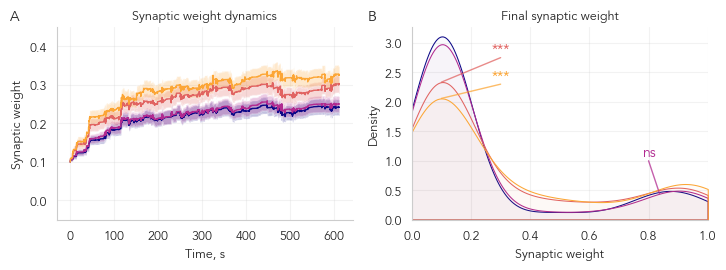

In [38]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8.4, 2.5))
axs = axs.flatten()

####################### Synaptic weight dynamics

ax = axs[0]

for condition in weights.keys():
    time = weights[condition].Time.to_numpy()
    
    ax.plot(
        time,
        weights[condition].Mean,
        linewidth = 1,
        color = colors[condition],
        label = condition
    )

    ax.fill_between(
        time, weights[condition].Mean - weights[condition].SEM, weights[condition].Mean + weights[condition].SEM,
        alpha = 0.25,
        color = colors[condition],
        edgecolor = None
    )
    
    # condition_fit = fit[ fit.Condition == condition ]
    # a1, tau1 = condition_fit.A1, condition_fit.Tau1
    # curve = [ rising_exp(t, a1, tau1) for t in time ]
    # 
    # ax.plot(
    #     time,
    #     curve,
    #     linewidth = 1,
    #     color = colors[condition],
    #     alpha = 0.75
    # )

ax.set_xlabel("Time, s")
ax.set_ylabel("Synaptic weight")

ax.set_title("Synaptic weight dynamics")

ax.set_ylim(-0.05, 0.45)
ax.set_yticks(np.arange(0, 0.5, 0.1))

ax.grid(alpha = 0.25)

####################### Final synaptic weights

ax = axs[1]

positions = {
    "0 Hz TI": [0.8, 1],
    "5 Hz TI": [0.3, 2.75],
    "130 Hz TI": [0.3, 2.3]
}

for condition in final_weights.keys():
    sns.kdeplot(
        final_weights[condition].Weight,
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.025,
        linewidth = 0.75,
        color = colors[condition]
    )

    if condition == "No TI": continue

    test_result = ks_result[(ks_result.Condition1 == "No TI") & (ks_result.Condition2 == condition)]
    star = test_result.Star.to_list()[0]
    location = test_result.StatisticLocation.to_list()[0]

    kde = gaussian_kde(final_weights[condition].Weight)
    where_y = kde(location)[0]
    where_x = location

    pos = positions[condition]
    
    ax.text(
        pos[0], pos[1],
        star,
        fontsize = 10,
        color = colors[condition],
        horizontalalignment = "center",
        verticalalignment = "bottom"
    )

    ax.plot(
        np.array([where_x, pos[0]]), # x
        np.array([where_y, pos[1]]), # y
        linewidth = 1,
        color = colors[condition],
        alpha = 0.75
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

ax.set_title("Final synaptic weight")

fig.text(x = 0.075, y = 0.92, s = "A", ha = "center", va = "center", fontsize = 10)
fig.text(x = 0.5, y = 0.92, s = "B", ha = "center", va = "center", fontsize = 10)

plt.savefig("bernstein-natural-3.png", dpi = 500, bbox_inches = "tight")